In [2]:
!pip install --upgrade tensorflow_datasets
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import matplotlib.pyplot as plt
from matplotlib import gridspec

import tensorflow as tf
import keras
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, concatenate, BatchNormalization, SpatialDropout2D, Activation, Flatten
from keras.models import Model

import numpy as np
import pandas as pd
import tensorflow_datasets as tfds
import glob

### Data loading and pre-processing functions

In [4]:
def preprocess_segmentation_mask(segmentation_mask):
    """preprocess the semgentation mask

    The original segmentation mask has three categories.
      foreground, background and outline
    This function will just convert it to foreground and background 

    The original segmentation mask is also 1-index, so will convert it
    to 0-index.

    the original mask is represented as:
    1 - edge of dog/cat and things like leashes etc.
    2 - background
    3 - foreground

    we want to just keep the merge the edges and foreground of the doggo/catto, and
    then treat it as a binary semantic segmentation task.
    To achieve this, we will just subtract two, converting to values of [-1, 0, 1],
    and then apply the abs function to convert the -1 values (edges) to the foreground.

    Will also convert it to 32 bit float which will be needed for working with tf.
    
    Why am I doing it this way?
     A reasonable question. Initially I tried to do it with just normal array indexing,
     but this is a bit more work since the mask is a tensorflow tensor and not a np array.
     We could alternatively convert it to an array, perform indexing and then map it back,
     but this would have a performance overhead, which wouldn't be a big deal, but still.
     With all that being said, I am doing it for you, so you don't have to.

    Args:
      segmentation_mask (array):
        original segmentation mask

    Returns:
      preprocessed segmentation_mask
    """
    return tf.abs(tf.cast(segmentation_mask, tf.float32) - 2)

def return_image_label_mask(ds_out):
    """ function to return image, class label and segmentation mask

    The original dataset contains additional information, such as the filename and
    the species. We don't care about any of that for this work, so will
    discard them and just keep the original image as our input, and then
    a tuple of our outputs that will be the class label and the semantic
    segmentation mask.

    Whilst we are here, we will also preprocess the segmentation mask.

    Args:
      ds_out: dict
        original dataset output

    Returns:
       RGB image
       tuple of class label and preprocessed segmentation mask
    """
    # preprocess the segmentation mask
    seg_mask =  preprocess_segmentation_mask(ds_out['segmentation_mask'])
    image = tf.cast(ds_out['image'], tf.float32)
    # image = standardise_image(image)
    return image, (ds_out['label'], seg_mask)

def mobilenet_preprocess_image(image):
    """Apply preprocessing that is suitable for MobileNetV3.
    
    Simply scales to ranges [-1, 1]
    
    
    you should use this preprocessing for both your model and the mobilenet model
    """
    image = (image - 127.5) / 255.0
    return image
        
def unprocess_image(image):
    """ undo preprocessing above so can plot images"""
    image = image * 255.0 + 127.5
    return image

def preprocess_and_resize(image, output, image_size):
    """apply preprocessing steps above to images and resize images and maps
    
    Each image in the dataset is of a different size. The resizing will make sure
    each image is the same size.
    """
    # resize the image and the semantic segmentation mask
    image = tf.image.resize(image, [image_size, image_size])
    image = mobilenet_preprocess_image(image)
    mask = tf.image.resize(output[1], [image_size, image_size])
    return image, (output[0], mask)

def flip_lr_augmentation(image, output, flip_lr_prob):
    """ function to return perform left-right flip augmentation

    The function will flip the image along the left-right axis with
    a defined probability.
    """

    # randomly sample a value between 0 and 1
    uniform_sample = tf.random.uniform([], minval=0, maxval=1)
    # perform flip_lr with probability given by flip_lr_prob 
    flip_lr_cond = tf.math.less(uniform_sample, flip_lr_prob)
    # output is a tuple of (class, segmentation_mask), pull out the segmentation mask
    seg = output[1]
    
    # wrapper fn for when we do the flip
    def flip():
        flipped_image = tf.image.flip_left_right(image)
        flipped_seg = tf.image.flip_left_right(seg)
        return flipped_image, flipped_seg

    # wrapper fn for when we do NOT flip
    def no_flip():
        return image, seg

    # apply augmentation    
    image, seg = tf.cond(flip_lr_cond, flip, no_flip)
    # return the image, and output
    return image, (output[0], seg)

def select_tasks(image, output, classification=True, segmentation=True):
    """select the tasks to include the data

    By default for each input there are two outputs. This function allows
    you to select which outputs to use, so the problem can be reduced to a
    single task problem for initial experimenting.    
    """
    # both tasks
    if classification and segmentation:
        return image, output
    # just classification
    elif classification:
        return image, output[0]
    # just segmentation
    elif segmentation:
        return image, output[1]
    # neither task, doesn't really make sense, so return the image
    # for a self-supervised task
    else:
        return image, image

class TrainForTime(keras.callbacks.Callback):
    """callback to terminate training after a time limit is reached

    Can be used to control how long training runs for, and will terminate
    training once a specified time limit is reached.
    """
    def __init__(
        self,
        train_time_mins=15,
    ):
        super().__init__()

        self.train_time_mins = train_time_mins
        self.epochs = 0
        self.train_time = 0
        self.end_early = False

    def on_train_begin(self, logs=None):
        # save the start time
        self.start_time = tf.timestamp()

    def on_epoch_end(self, epoch, logs=None):
        self.epochs += 1
        current_time = tf.timestamp()
        training_time = (current_time - self.start_time)
        if (training_time / 60) > self.train_time_mins:
            self.train_time = current_time - self.start_time
            self.model.stop_training = True
            self.end_early = True


    def on_train_end(self, logs=None):
        if self.end_early:
            print('training time exceeded and ending early')
            print(f'training ended on epoch {self.epochs}')
            print(f'training time = {self.train_time / 60} mins')

In [5]:
import tensorflow as tf

def minimal_segmentation_augmentations(image, output, flip_prob=0.5, max_shift=10):
    """
    Minimal augmentations using only tf.image (no tensorflow_addons):
    - Horizontal flip
    - Small translation via pad + crop
    """
    label, mask = output

    # --- 1. Flip Left-Right ---
    if tf.random.uniform([]) < flip_prob:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # --- 2. Small Translation (Pad + Crop) ---
    dx = tf.random.uniform([], -max_shift, max_shift + 1, dtype=tf.int32)
    dy = tf.random.uniform([], -max_shift, max_shift + 1, dtype=tf.int32)

    def translate_tensor(tensor, dx, dy):
        shape = tf.shape(tensor)
        height = shape[0]
        width = shape[1]

        pad_top = tf.maximum(dy, 0)
        pad_bottom = tf.maximum(-dy, 0)
        pad_left = tf.maximum(dx, 0)
        pad_right = tf.maximum(-dx, 0)

        padded = tf.pad(tensor, [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]], mode='REFLECT')
        cropped = tf.image.crop_to_bounding_box(
            padded,
            offset_height=pad_bottom,
            offset_width=pad_right,
            target_height=height,
            target_width=width
        )
        return cropped

    image = translate_tensor(image, dx, dy)
    mask = translate_tensor(mask, dx, dy)

    return image, (label, mask)

In [6]:
def brightness_contrast_jitter(image, output):
    image = tf.image.random_brightness(image, max_delta=0.05)  # ±5% brightness
    image = tf.image.random_contrast(image, lower=0.95, upper=1.05)  # ±5% contrast
    return image, output

In [7]:
def random_hue_jitter(image, output, max_delta=0.05):
    """
    Apply random hue adjustment to the image.
    `max_delta` should be in the range [0, 0.5].
    """
    image = tf.image.random_hue(image, max_delta=max_delta)
    return image, output

### Data Loader

In [9]:
def load_oxford_pets(split,
                     batch_size=233,
                     classification=True,
                     segmentation=True,
                     shuffle=True,
                     augment=True,
                     image_size=300):
    """Load Oxford pets dataset for Assignment 1B

    Function handles loading of data for 1b, included processing of images and
    semantic segmentation masks. This function will
    organise the tensorflow dataset to return an output that is a tuple, where
    the tuple will be (classification_labels, segmentation_masks).

    Parameters
    ----------
    split : string
        either train, val or test string
    classification : bool
        whether to include classification labels
    segmentation : bool
        whether to include semantic segmentation masks
    batch_size : int
        size of batches to use
    shuffle : bool
        whether to shuffle the dataset (WILL ONLY APPLY TO TRAIN)
    augment : bool
        whether to augment the dataset (WILL ONLY APPLY TO TRAIN)
    image_size : int
        new image size

    Returns
    -------
       tf.Dataset containing the Oxford pets dataset
    """
    # lets do some error checking first
    # Check fior a valid dataset split, this must be train or test
    if (split != 'train') and (split != 'val') and (split != 'test'):
        raise ValueError('Arg for split must be either \'train\' or \'test\'')
    if (not classification) and (not segmentation):
        print("WARNING: One of the tasks (classification and segmentation) must be selected")
        print("Setting both to enabled")
        classification = True
        segmentation = True
        
    # check that if using the val split, shuffle if false. If not, print a warning and force shuffle to be false
    if (split == 'val') and shuffle:
        print("WARNING: shuffle is set to true, but have specified split to be \'val\'")
        print('The shuffle argument will be ignored')
        shuffle = False
        
    # check that if using the test split, shuffle if false. If not, print a warning and force shuffle to be false
    if (split == 'test') and shuffle:
        print("WARNING: shuffle is set to true, but have specified split to be \'test\'")
        print('The shuffle argument will be ignored')
        shuffle = False
        
    # check that if using the val split, augment if false. If not, print a warning and force augment to be false
    if (split == 'val') and augment:
        print("WARNING: augment is set to true, but have specified split to be \'val\'")
        print('The augment argument will be ignored')
        augment = False
        
    # check that if using the test split, augment if false. If not, print a warning and force augment to be false
    if (split == 'test') and augment:
        print("WARNING: augment is set to true, but have specified split to be \'test\'")
        print('The augment argument will be ignored')
        augment = False
        
    # the dataset by default only has train and test splits. If val is requested, pull the first 30% of the test set
    if (split == 'val'):
        split = 'test[:30%]'
    # the test set then becomes the remaining 70% of the original test set
    elif (split == 'test'):
        split = 'test[30%:]'
   
    # now start loading the dataset
    ds = tfds.load('oxford_iiit_pet',
                   split=split,
                   with_info=False)
    
    # remove unnecessary dataset info
    ds = ds.map(return_image_label_mask)

    # augmentation
    # only apply if in the training split and augment has been set to True
    if split == 'train' and augment:
        # apply a left-right flip with 50% probability
        flip_lr_prob = 0.5
        # flip operation
        ds = ds.map(lambda inp, out: flip_lr_augmentation(inp, out, flip_lr_prob), num_parallel_calls=tf.data.AUTOTUNE)

        # more augmentation operations could go here .....
    
    # apply additional image augmentations
    ds = ds.map(minimal_segmentation_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(brightness_contrast_jitter, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(random_hue_jitter, num_parallel_calls=tf.data.AUTOTUNE)

    # Final processing of the data 
    # here we will resize the data, and add the preprocessing that is needed for compatability with the mobilenet models.
    ds = ds.map(lambda inp, out: preprocess_and_resize(inp, out, image_size))

    # and now remove any tasks that we don't want. Note that we call this last as it means that all the other functions
    # can safely assume that data for both tasks is in the dataset
    ds = ds.map(lambda inp, out: select_tasks(inp, out, classification, segmentation))

    # if in the training split, and shuffle is true, shuffle the data
    if split == 'train' and shuffle:
        ds = ds.shuffle(1000)

    # return the loaded and processed dataset
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

### Testing the provided data loader.

In [11]:
# testing the data loader and plotting some images.
# NOTE: the image size set here is all but definitely too large. You will need
# to chage this yourself to something that is suitable given your constraints
# NOTE: The batch size is also too large. This done on purpose force you to 
# pick a suitable batch size yourself
image_size = 128
batch_size = 32
# load training data, note that shuffle and augment are true
train_class_seg = load_oxford_pets('train', classification=True, segmentation=True, shuffle=True, augment=True, 
                                   batch_size=batch_size, image_size=image_size)
# Load validation data, note that shuffle and augment are false (though if they weren't, the data loader would force these to be false)
val_class_seg = load_oxford_pets('val', classification=True, segmentation=True, shuffle=False, augment=False, 
                                 batch_size=batch_size, image_size=image_size)
# load testing data, note that shuffle and augment are false (though if they weren't, the data loader would force these to be false)
test_class_seg = load_oxford_pets('test', classification=True, segmentation=True, shuffle=False, augment=False, 
                                  batch_size=batch_size, image_size=image_size)

(32, 128, 128, 1)
(32, 128, 128, 1)
(32, 128, 128, 1)


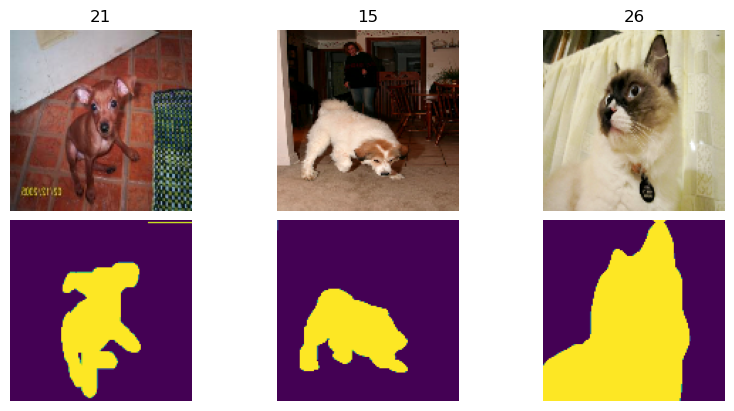

In [12]:
# lets plot a few now to see some good kittens/doggos
fig, axs = plt.subplots(2, 3, figsize=(8, 4), layout="constrained")
num_plot = 3
i = 0

# each sample of our dataset will be of the format
# image, outputs
# where outputs[0] = label
#       outputs[1] = segmentation mask
#
#
# lets get a single batch, and plot just a few of them
for image, output in train_class_seg.take(1).as_numpy_iterator(): 
    for i in range(num_plot): 
        im = axs[0, i].imshow(np.squeeze(unprocess_image(image[i, ...])) / 255.0)
        axs[0, i].set_title(output[0][i])
        axs[0, i].axis('off')
        im = axs[1, i].imshow(np.squeeze(output[1][i, ...]))
        axs[1, i].axis('off')
        
        print(output[1].shape)
        i += 1
        if i >= num_plot:
            break
        
plt.savefig('doggos_cattos.png')

The images are showing correctly.

In [14]:
# classification only; classification = True, segmentation = False (note batch size is 1 here)
train_class_only = load_oxford_pets('train', classification=True, segmentation=False, shuffle=True, augment=True, batch_size=1, image_size=image_size)
# segmentation only; classification = False, segmentation = True (note batch size is 1 here)
train_seg_only = load_oxford_pets('train', classification=False, segmentation=True, shuffle=True, augment=True, batch_size=1, image_size=image_size)

# test the classification only dataset
# pull out one element
inp, out = next(iter(train_class_only))
# print the output
print(out.numpy())

# test the segmentation only dataset
# pull out one element
inp, out = next(iter(train_seg_only))
# print just the output shape for the segmentation output 
print(out.numpy().shape)

[4]
(1, 128, 128, 1)


### Loading MobileNetV3Small base for fine tuning

This model can be loaded directly from keras. By default, the model we download will be pre-trained on Imagenet dataset.

Note that we will need to set the preprocessing option when loading this base network to False. This is because the `include_preprocessing` step is implemented in the Datasets we defined above.

We also set `include_top=False`, to avoid loading our model with the final Dense classification layer which is used for the original Imagenet model.

More details are available in the keras documentation [here](https://keras.io/api/applications/mobilenet/).

In [16]:
mobile_base = keras.applications.MobileNetV3Small(input_shape=(image_size, image_size, 3),
                                                  include_top=False,
                                                  include_preprocessing=False)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


In [20]:
# Set Reasonable Values 
image_size = 128
batch_size = 32    

# Data Loaders Setup
train_class_seg = load_oxford_pets('train', classification=True, segmentation=True, shuffle=True, augment=True,
                                   batch_size=batch_size, image_size=image_size)

val_class_seg = load_oxford_pets('val', classification=True, segmentation=True, shuffle=False, augment=False,
                                 batch_size=batch_size, image_size=image_size)

test_class_seg = load_oxford_pets('test', classification=True, segmentation=True, shuffle=False, augment=False,
                                  batch_size=batch_size, image_size=image_size)

# Non-Shuffled Training Set
train_class_seg_ns = load_oxford_pets('train', classification=True, segmentation=True, shuffle=False, augment=True,
                                      batch_size=batch_size, image_size=image_size)

In [22]:
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Input, Dropout
from keras.models import Model

def build_multitask_model(image_size, num_classes=37):
    # --- Input ---
    input_img = Input(shape=(image_size, image_size, 3), name="input_image")

    # --- Encoder / Backbone ---
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)

    # Shared features before branching
    shared_features = x

    # --- Classification Head ---
    cls = MaxPooling2D((2, 2))(shared_features)
    cls = Flatten()(cls)
    cls = Dense(128, activation='relu')(cls)
    cls = Dropout(0.5)(cls)
    classification_output = Dense(num_classes, activation='softmax', name='classification_output')(cls)

    # --- Decoder / Segmentation Head ---
    seg = Conv2D(128, (3, 3), activation='relu', padding='same')(shared_features)
    seg = UpSampling2D((2, 2))(seg)

    seg = Conv2D(64, (3, 3), activation='relu', padding='same')(seg)
    seg = UpSampling2D((2, 2))(seg)

    seg = Conv2D(32, (3, 3), activation='relu', padding='same')(seg)
    seg = UpSampling2D((2, 2))(seg)

    segmentation_output = Conv2D(1, (1, 1), activation='sigmoid', name='segmentation_output')(seg)

    # --- Define the Model ---
    model = Model(inputs=input_img, outputs=[classification_output, segmentation_output])

    return model

In [23]:
model = build_multitask_model(image_size, num_classes=37)

model.compile(optimizer='adam',
              loss=['sparse_categorical_crossentropy', 'binary_crossentropy'],
              metrics={'classification_output': 'accuracy', 'segmentation_output': 'accuracy'})

In [24]:
epochs = 15

history_scratch = model.fit(train_class_seg,
          validation_data=val_class_seg,
          epochs=epochs,
          verbose=True)

Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 107s 888ms/step - classification_output_accuracy: 0.0292 - classification_output_loss: 3.6205 - loss: 4.2517 - segmentation_output_accuracy: 0.6157 - segmentation_output_loss: 0.6312 - val_classification_output_accuracy: 0.0463 - val_classification_output_loss: 3.5954 - val_loss: 4.1123 - val_segmentation_output_accuracy: 0.7420 - val_segmentation_output_loss: 0.5182
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 102s 856ms/step - classification_output_accuracy: 0.0492 - classification_output_loss: 3.5872 - loss: 4.0614 - segmentation_output_accuracy: 0.7719 - segmentation_output_loss: 0.4742 - val_classification_output_accuracy: 0.0572 - val_classification_output_loss: 3.5184 - val_loss: 3.9412 - val_segmentation_output_accuracy: 0.7997 - val_segmentation_output_loss: 0.4245
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 103s 865ms/step - classification_output_accuracy: 0.0654 - classification_output_loss: 3.5194 - loss: 3.9470 - segmentation_output_accuracy:

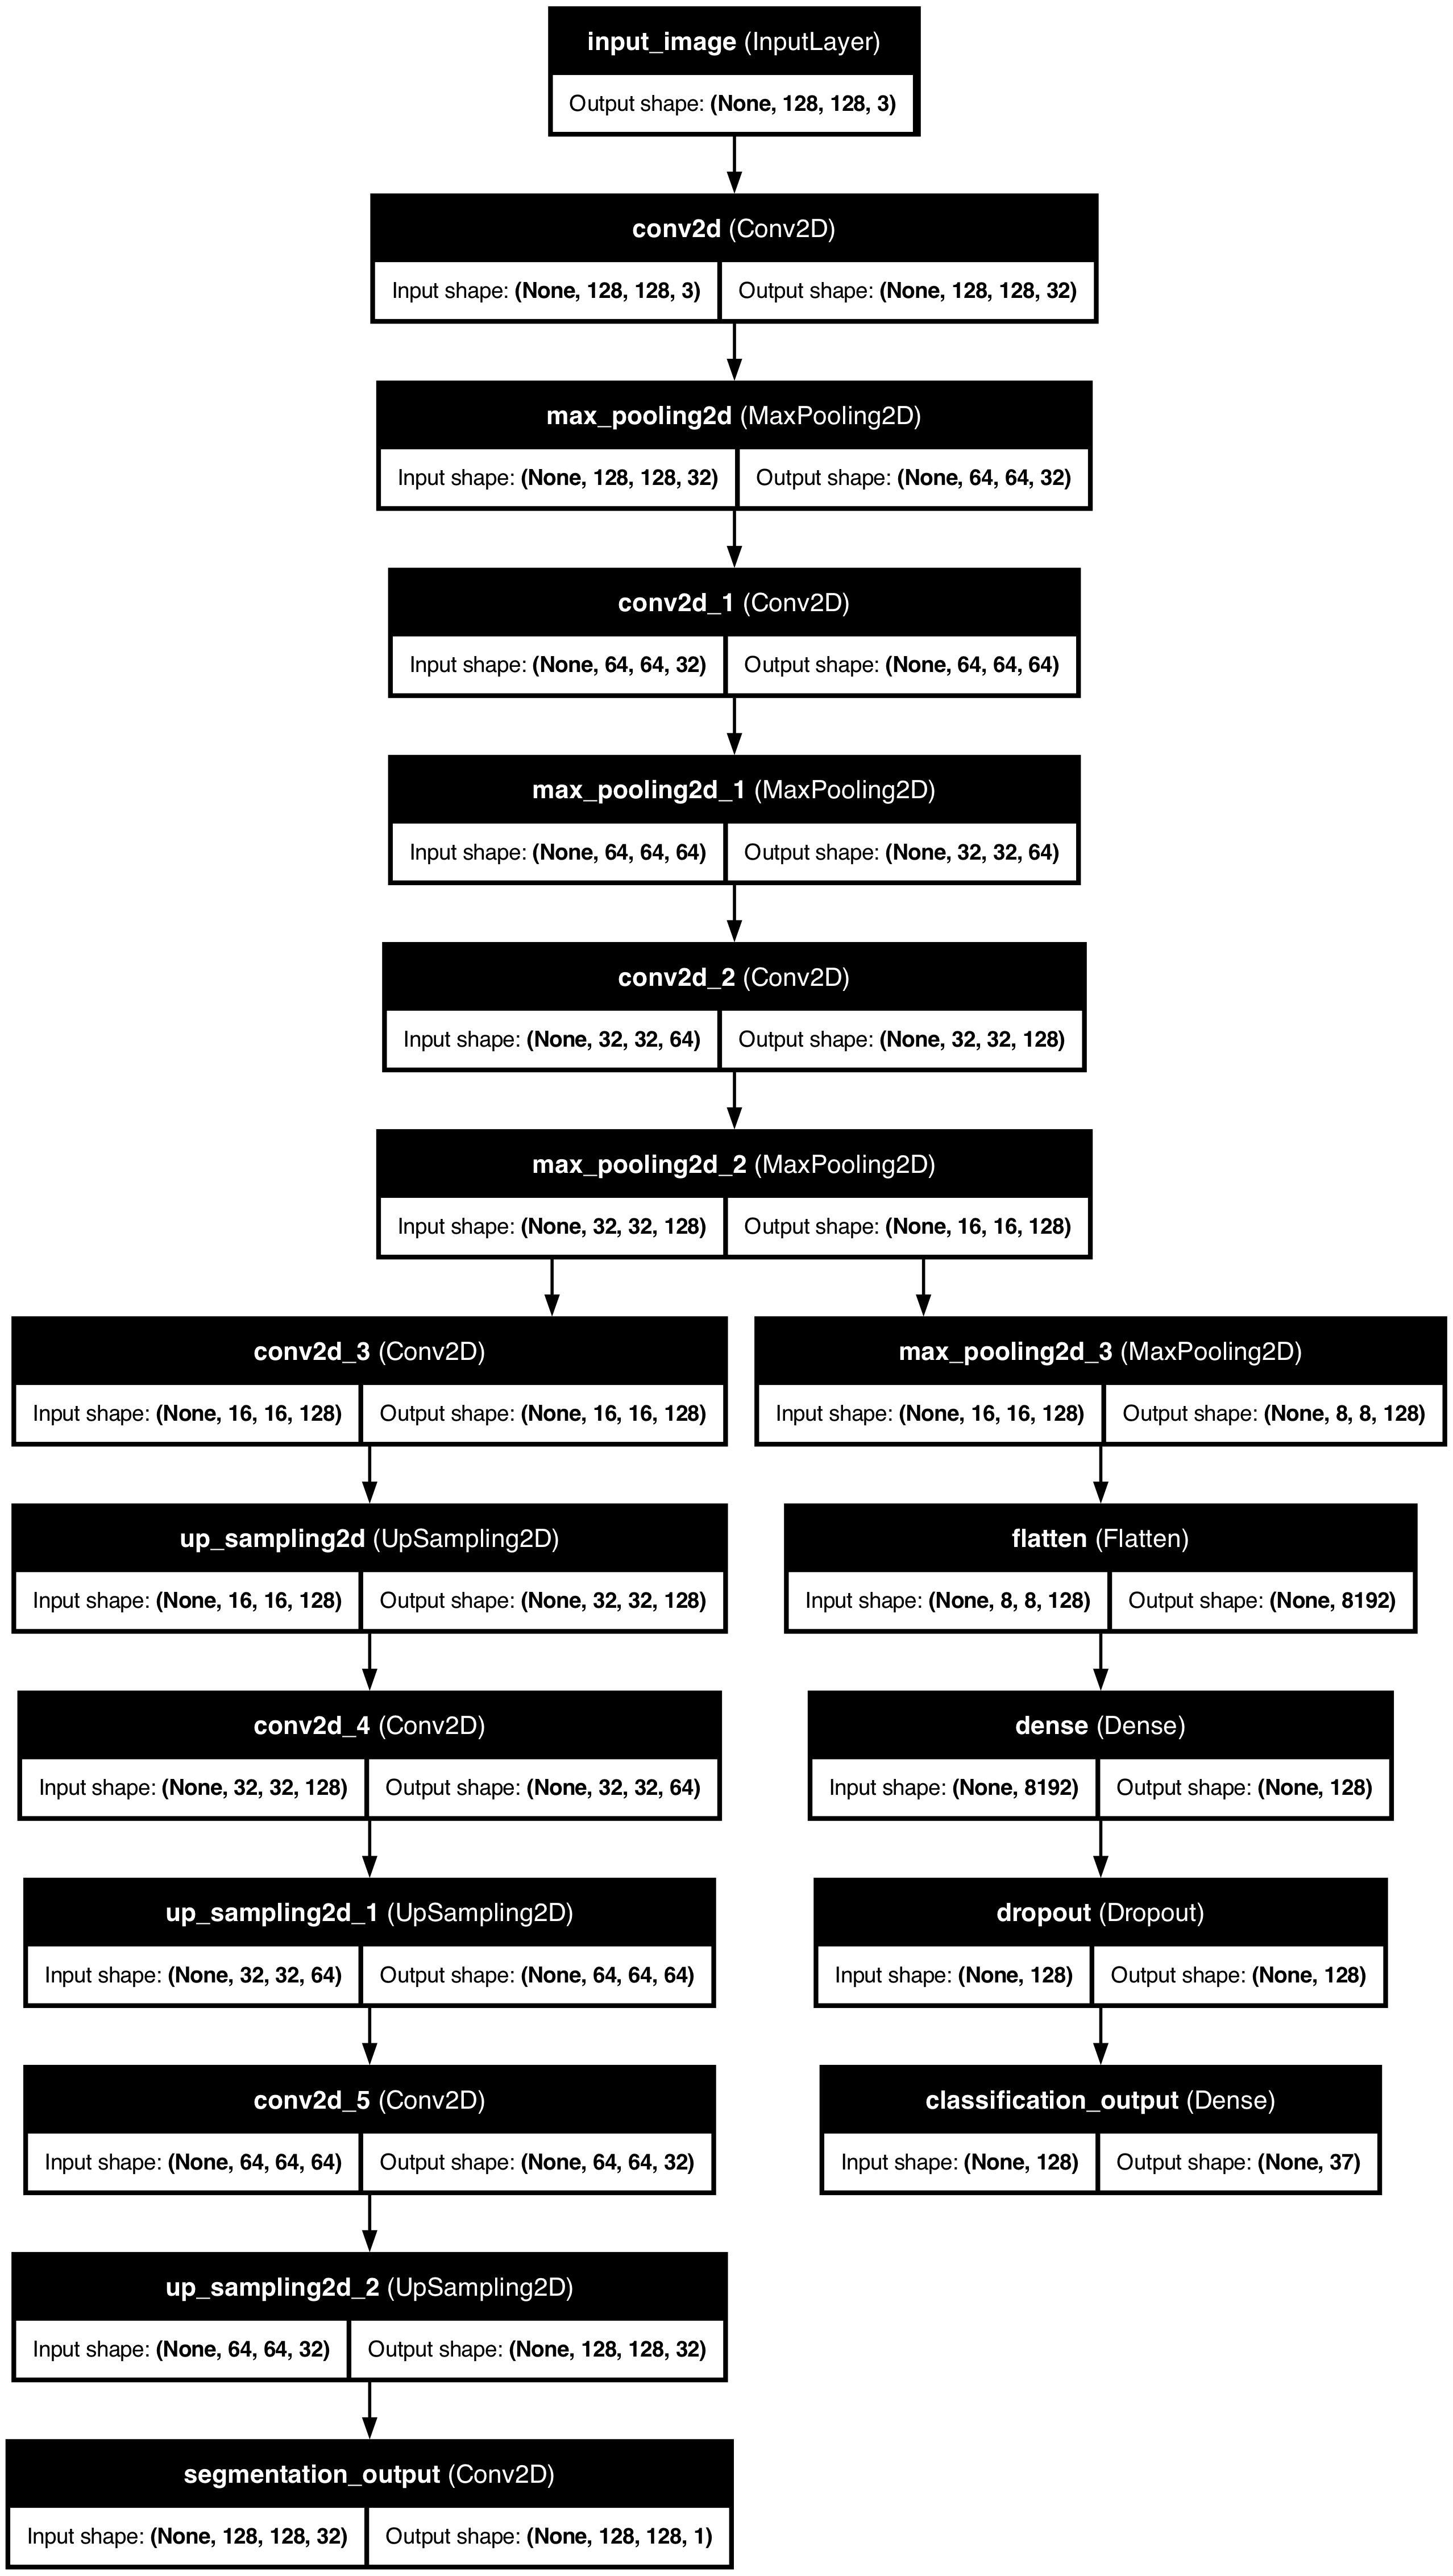

In [79]:
from tensorflow.keras.utils import plot_model

# Save model architecture as a PNG file
plot_model(model, 
           to_file='model_architecture.png', 
           show_shapes=True, 
           show_layer_names=True)


## Fine-tuned MobileNet


In [27]:
from keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D, Conv2D, UpSampling2D,
    BatchNormalization, Activation, Resizing
)
from keras.models import Model
from keras.applications import MobileNetV3Small

def build_mobilenet_multitask_model(image_size, num_classes=37):
    # --- Input ---
    input_img = Input(shape=(image_size, image_size, 3), name="input_image")

    # --- MobileNetV3Small Backbone ---
    mobile_base = MobileNetV3Small(
        input_shape=(image_size, image_size, 3),
        include_top=False,
        include_preprocessing=False,
        weights='imagenet'
    )
    mobile_base.trainable = True  # or False initially if freezing layers first

    features = mobile_base(input_img)

    # --- Classification Head ---
    cls = GlobalAveragePooling2D()(features)
    cls = Dense(128)(cls)
    cls = BatchNormalization()(cls)
    cls = Activation('relu')(cls)
    cls = Dense(64)(cls)
    cls = BatchNormalization()(cls)
    cls = Activation('relu')(cls)
    classification_output = Dense(num_classes, activation='softmax', name='classification_output')(cls)

    # --- Segmentation Head ---
    seg = Conv2D(128, (3, 3), activation='relu', padding='same')(features)
    seg = UpSampling2D((2, 2))(seg)
    seg = Conv2D(64, (3, 3), activation='relu', padding='same')(seg)
    seg = UpSampling2D((2, 2))(seg)
    seg = Conv2D(32, (3, 3), activation='relu', padding='same')(seg)
    seg = UpSampling2D((2, 2))(seg)
    seg = Resizing(image_size, image_size)(seg)  # force output size = input
    segmentation_output = Conv2D(1, (1, 1), activation='sigmoid', name='segmentation_output')(seg)

    # --- Final Model ---
    model = Model(inputs=input_img, outputs=[classification_output, segmentation_output])
    return model

In [28]:
model_mobilenet = build_mobilenet_multitask_model(image_size, num_classes=37)

model_mobilenet.compile(
    optimizer='adam',
    loss={
        'classification_output': 'sparse_categorical_crossentropy',
        'segmentation_output': 'binary_crossentropy'
    },
    loss_weights={
        'classification_output': 1.0,
        'segmentation_output': 2.0
    },
    metrics={
        'classification_output': 'accuracy',
        'segmentation_output': 'accuracy'
    }
)

# Train model
history_mobilenet = model_mobilenet.fit(
    train_class_seg,
    validation_data=val_class_seg,
    epochs=epochs,
    verbose=True
)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 67s 430ms/step - classification_output_accuracy: 0.1377 - classification_output_loss: 3.3189 - loss: 4.3814 - segmentation_output_accuracy: 0.7662 - segmentation_output_loss: 0.5312 - val_classification_output_accuracy: 0.1571 - val_classification_output_loss: 3.6093 - val_loss: 4.2996 - val_segmentation_output_accuracy: 0.8517 - val_segmentation_output_loss: 0.3454
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 54s 438ms/step - classification_output_accuracy: 0.5555 - classification_output_loss: 1.8086 - loss: 2.3430 - segmentation_output_accuracy: 0.8797 - segmentation_output_loss: 0.2672 - val_classification_output_accuracy: 0.1471 - val_classification_output_loss: 3.7466 - val_loss: 4.4740 - val_segmentation_output_accuracy: 0.8432 - val_segmentation_output_loss: 0.3647
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 67s 549ms/step - classification_output_accuracy: 0.6856 - classification_output_loss: 1.2149 - loss: 1.7065 - segmentation_output_accuracy: 0.

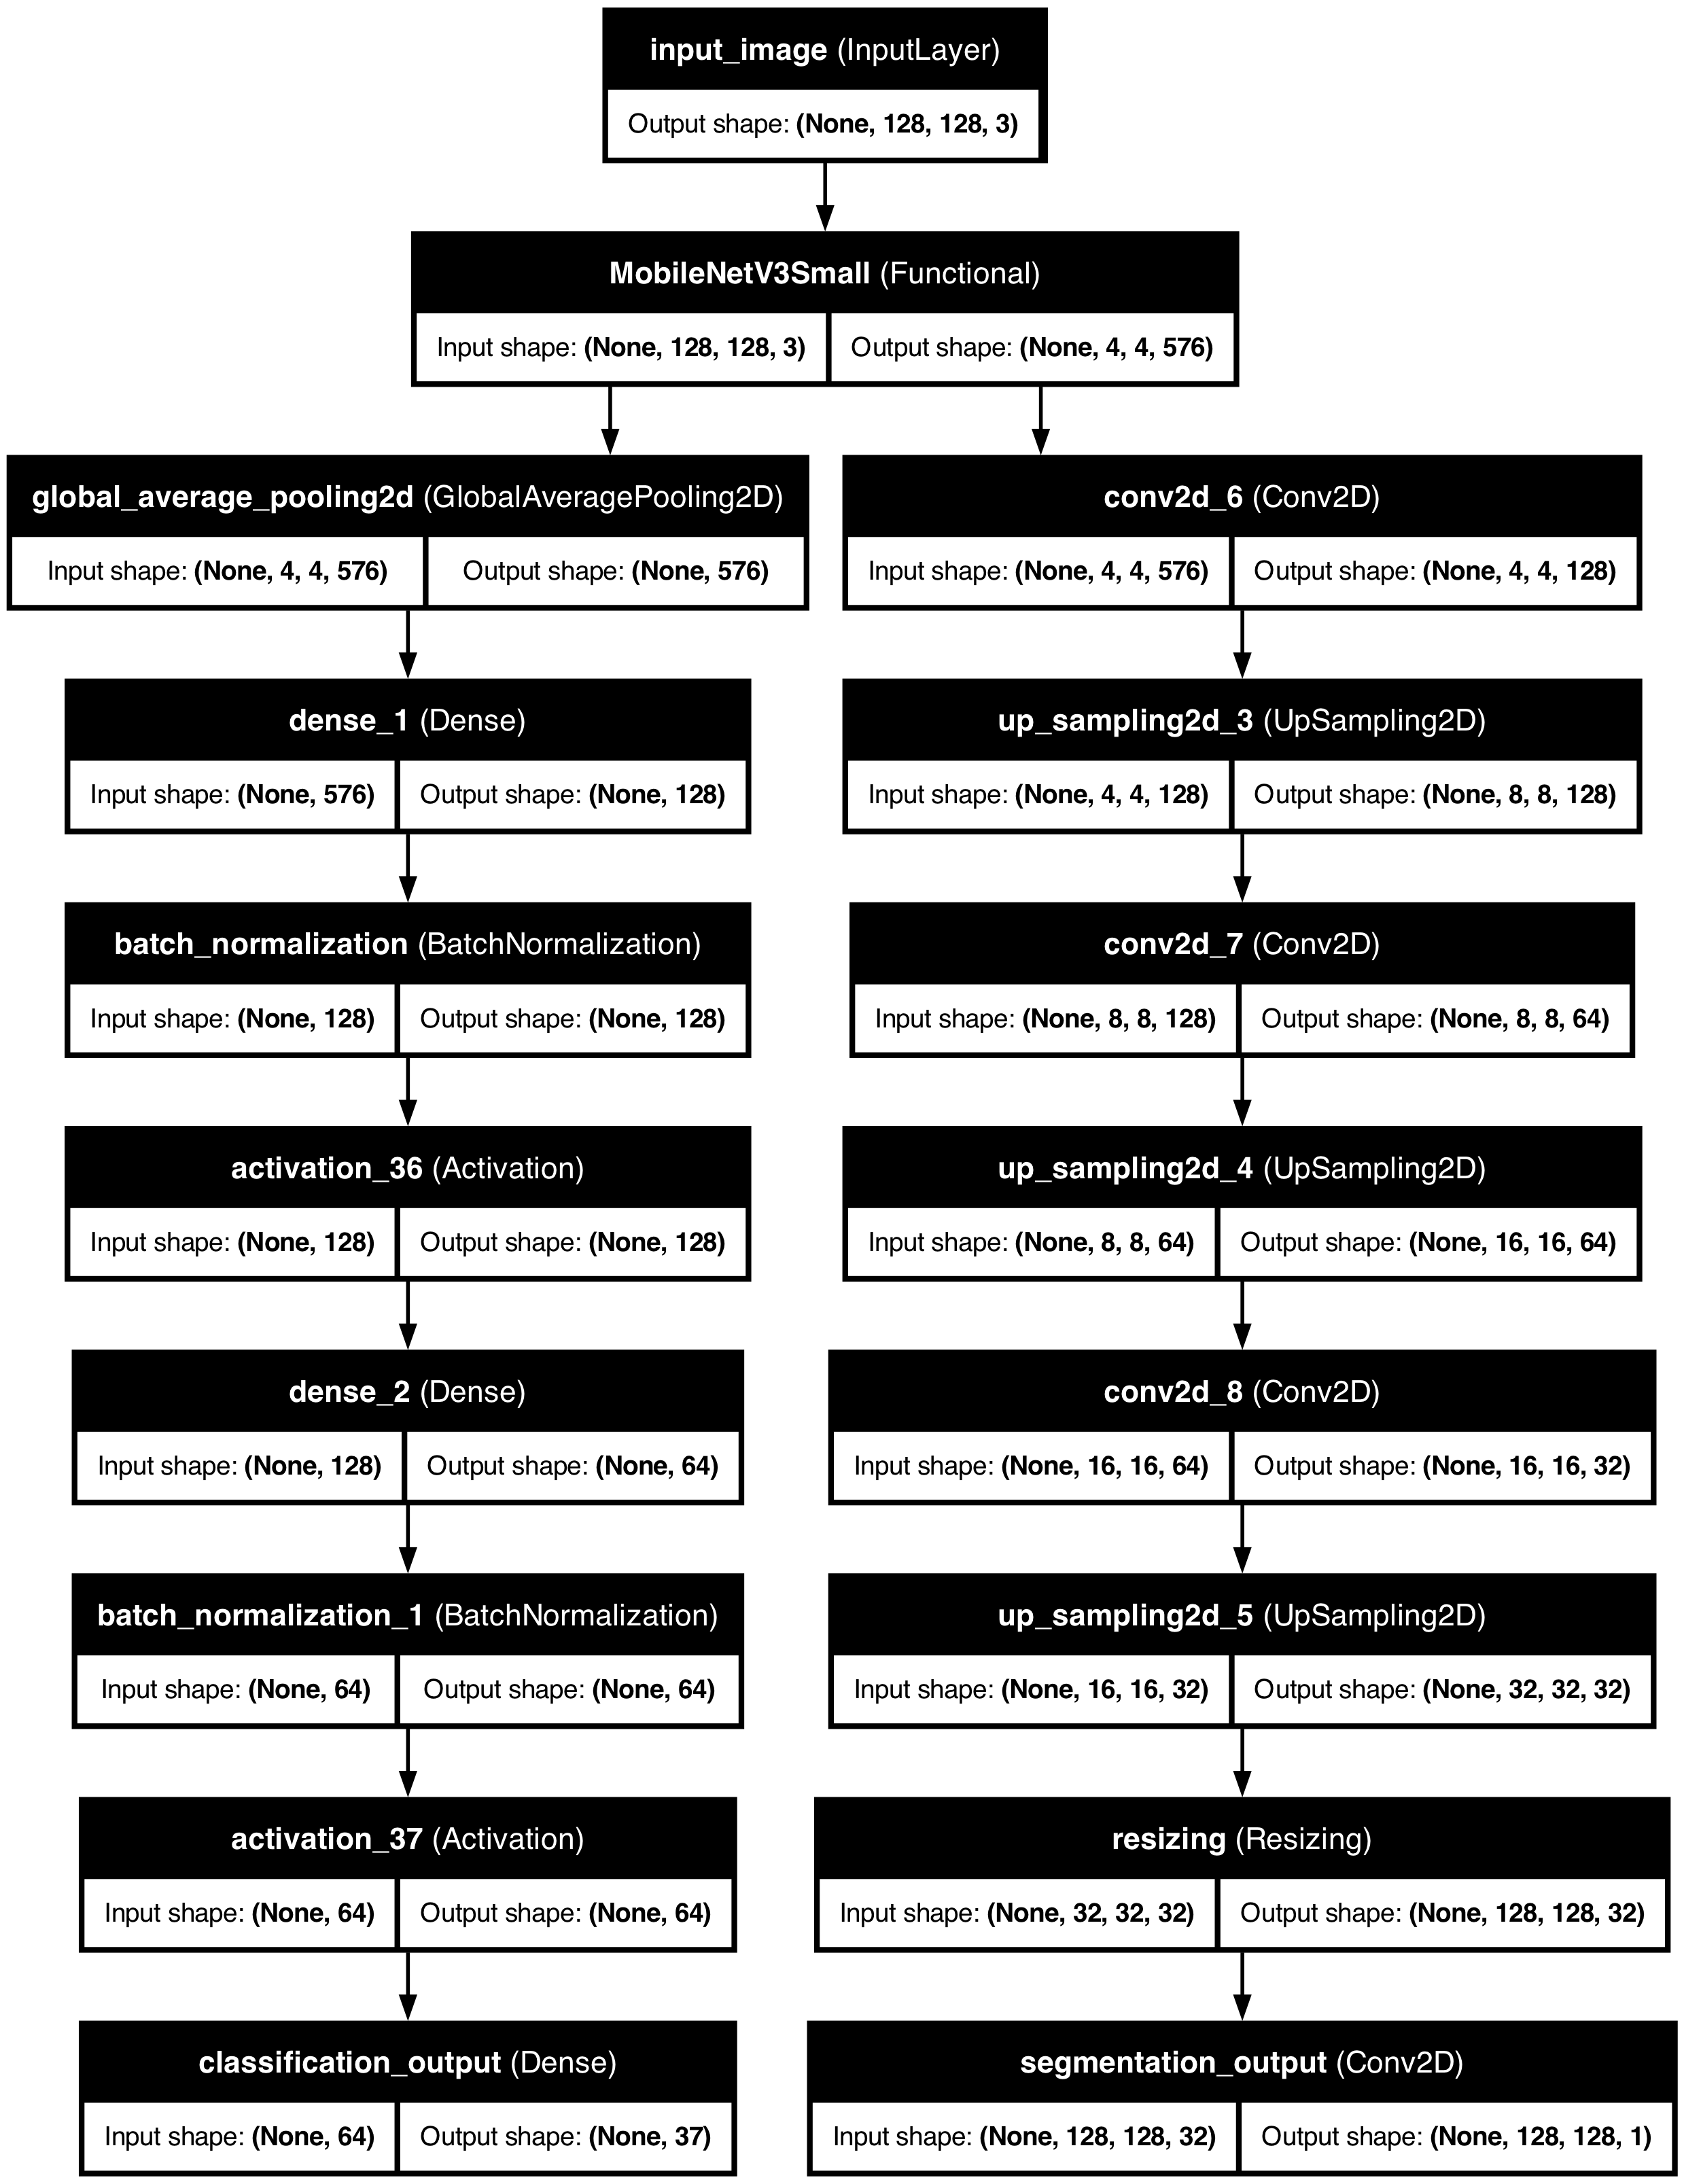

In [77]:
from tensorflow.keras.utils import plot_model

# Save model architecture as a PNG file
plot_model(model_mobilenet, 
           to_file='model_mobilenet_architecture.png', 
           show_shapes=True, 
           show_layer_names=True)


In [30]:
#
# Evaluation
#
# You should evaluate both your networks for both tasks. To help generate metrics and plots, you may want to pull out the labels from the dataset
# which you could do with something like the following:
#
# y_class_test = np.concatenate([y[0] for x,y in test_class_seg.as_numpy_iterator()])
# y_seg_test = np.concatenate([y[1] for x,y in test_class_seg.as_numpy_iterator()])
# 
# For evaluating the two tasks, the classification task is just like all the other classification tasks you've done this semseter and you can follow
# how these have been dealt with. For the segmentation task, one way to look at this is as a binary classification task as you're classifiying each 
# pixel into foreground and background. With that in mind you could do something like this:
#
# class_preds, seg_preds = my_awesome_network.predict(test_class_seg)
# seg_preds_flat = seg_preds.reshape(-1) > 0.5 # flatten predictions, turn into boolean vector where true is fgnd and false is bkgnd
# seg_gt_flat = y_seg_test.reshape(-1) > 0.5 # same as above, but for the ground truth, need to have both as a boolean vector
# cm = sklearn.metrics.confusion_matrix(seg_gt_flat, seg_preds_flat)
#
# You could also look at other segmentation specific metrics as a way to evaluate performance

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_heatmap(y_true, y_pred, labels=None, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    if labels is None:
        labels = list(range(cm.shape[0]))

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Count'})
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, jaccard_score
)

def eval_models(model, test_dataset, history=None, name="Model"):
    print(f"\n Evaluation for: {name}")

    # --- Extract ground truth ---
    y_class_test = np.concatenate([y[0] for x, y in test_dataset.as_numpy_iterator()])
    y_seg_test = np.concatenate([y[1] for x, y in test_dataset.as_numpy_iterator()])

    # --- Predictions ---
    class_preds, seg_preds = model.predict(test_dataset)
    y_class_pred = np.argmax(class_preds, axis=1)

    # --- Classification Evaluation ---
    print("\n Classification Task")
    print("Accuracy:", accuracy_score(y_class_test, y_class_pred))
    print("Classification Report:\n", classification_report(y_class_test, y_class_pred))

    # Plot Confusion Matrix
    plot_confusion_matrix_heatmap(y_class_test, y_class_pred, 
                                  title="Confusion Matrix - Classification")


    # --- Segmentation Evaluation ---
    print("\n Segmentation Task")
    seg_preds_flat = seg_preds.reshape(-1) > 0.5
    seg_gt_flat = y_seg_test.reshape(-1) > 0.5
    
    print("Accuracy:", accuracy_score(seg_gt_flat, seg_preds_flat))
    print("Precision:", precision_score(seg_gt_flat, seg_preds_flat))
    print("Recall:", recall_score(seg_gt_flat, seg_preds_flat))
    print("F1 Score:", f1_score(seg_gt_flat, seg_preds_flat))

    plot_confusion_matrix_heatmap(seg_gt_flat, seg_preds_flat, labels=["Background", "Foreground"], 
                                  title="Confusion Matrix - Segmentation")


    # --- Plot Training History if provided ---
    if history:
        fig = plt.figure(figsize=(14, 6))

        ax1 = fig.add_subplot(1, 2, 1)
        ax1.plot(history.history['loss'], label='Train Loss')
        ax1.plot(history.history['val_loss'], label='Val Loss')
        ax1.set_title("Overall Loss")
        ax1.legend()

        if 'classification_output_accuracy' in history.history:
            ax2 = fig.add_subplot(1, 2, 2)
            ax2.plot(history.history['classification_output_accuracy'], label='Train Classification Acc')
            ax2.plot(history.history['val_classification_output_accuracy'], label='Val Classification Acc')
            ax2.set_title("Classification Accuracy")
            ax2.legend()

        plt.tight_layout()
        plt.show()


 Evaluation for: From Scratch CNN
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 293ms/step

 Classification Task
Accuracy: 0.2632398753894081
Classification Report:
               precision    recall  f1-score   support

           0       0.17      0.19      0.18        69
           1       0.17      0.42      0.24        66
           2       0.19      0.09      0.12        70
           3       0.23      0.37      0.28        65
           4       0.22      0.24      0.23        75
           5       0.44      0.40      0.42        67
           6       0.34      0.34      0.34        70
           7       0.37      0.52      0.43        60
           8       0.18      0.10      0.13        67
           9       0.25      0.28      0.26        64
          10       0.16      0.20      0.18        66
          11       0.42      0.47      0.44        68
          12       0.05      0.01      0.02        73
          13       0.21      0.06      0.09        72
          14       0.24      0.30    

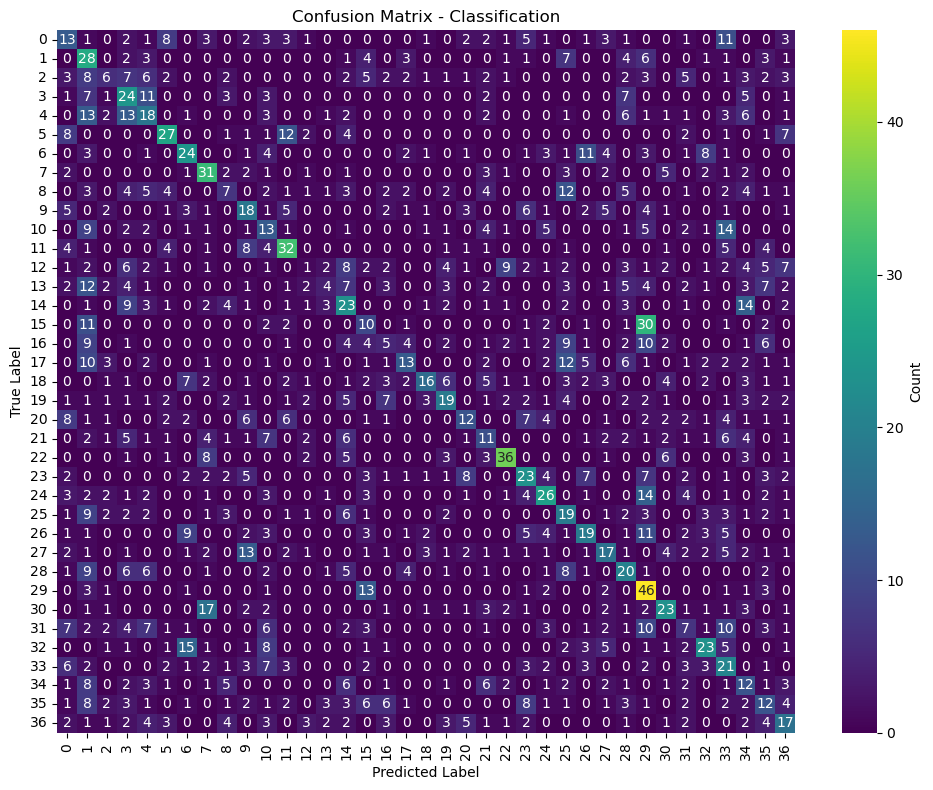


 Segmentation Task
Accuracy: 0.7913136705059871
Precision: 0.7599141615076391
Recall: 0.7431624989739367
F1 Score: 0.7514449823081705


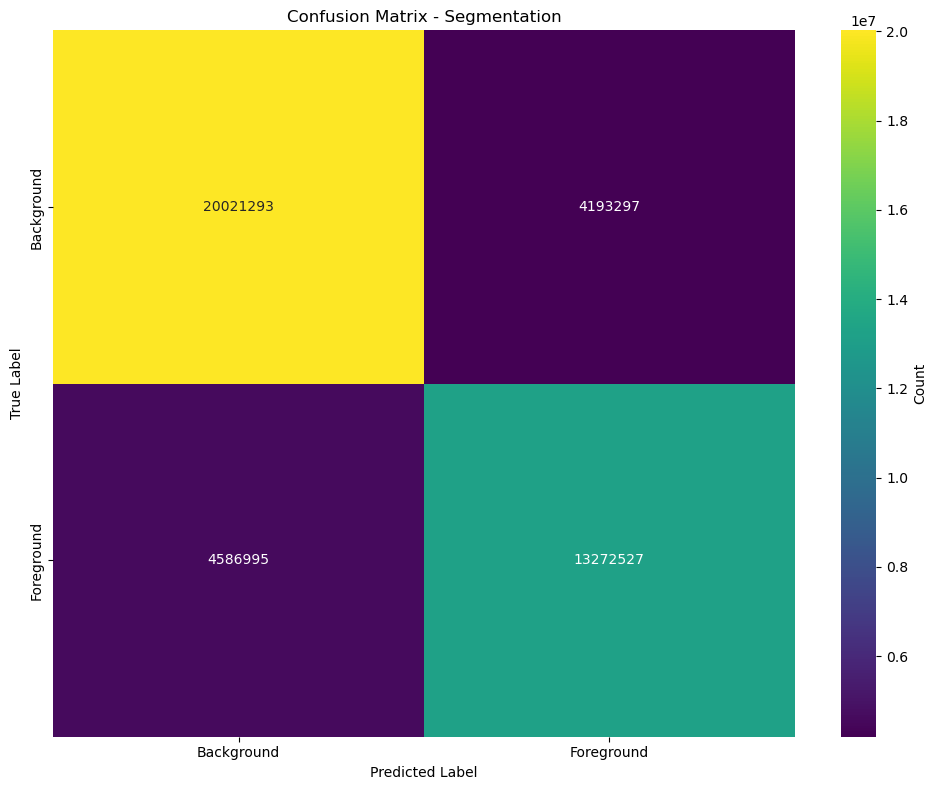

In [33]:
eval_models(model, test_class_seg, name="From Scratch CNN")


 Evaluation for: Fine-Tuned MobileNet
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step

 Classification Task
Accuracy: 0.4692367601246106
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.55      0.58        69
           1       0.34      0.41      0.37        66
           2       0.67      0.06      0.11        70
           3       0.58      0.17      0.26        65
           4       0.45      0.56      0.50        75
           5       0.54      0.19      0.29        67
           6       0.42      0.61      0.50        70
           7       0.90      0.47      0.62        60
           8       0.42      0.49      0.46        67
           9       0.31      0.67      0.43        64
          10       0.37      0.11      0.16        66
          11       0.43      0.96      0.59        68
          12       0.35      0.23      0.28        73
          13       0.67      0.11      0.19        72
          14       0.44      0.74

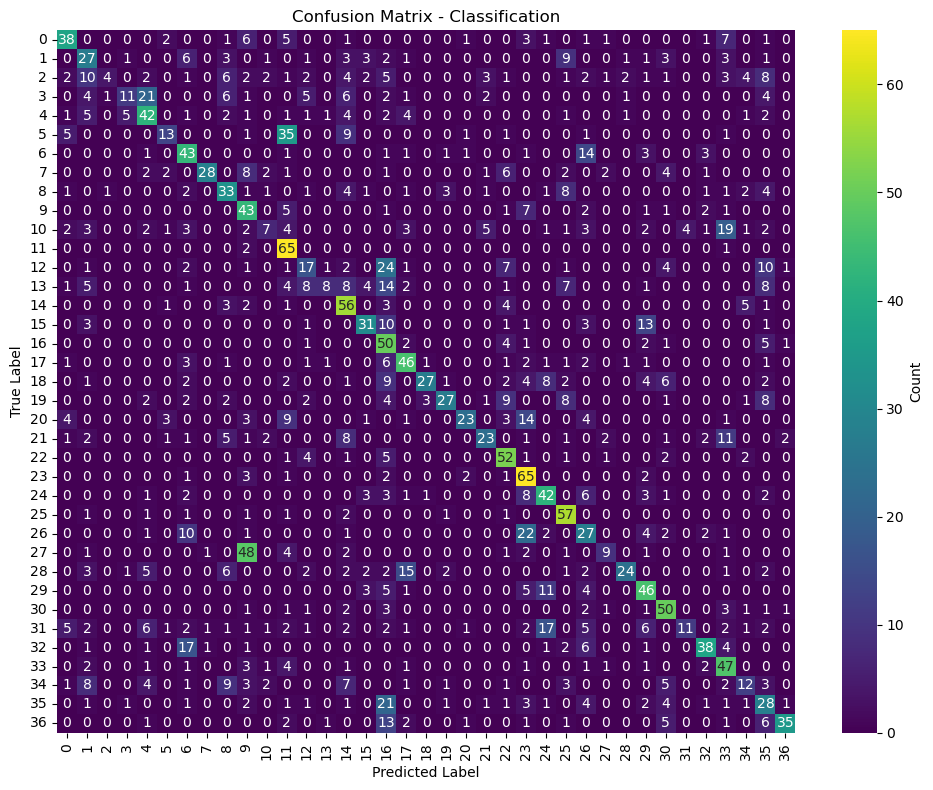


 Segmentation Task
Accuracy: 0.8154303054571894
Precision: 0.8055216419034085
Recall: 0.7449044698717497
F1 Score: 0.7740280779266143


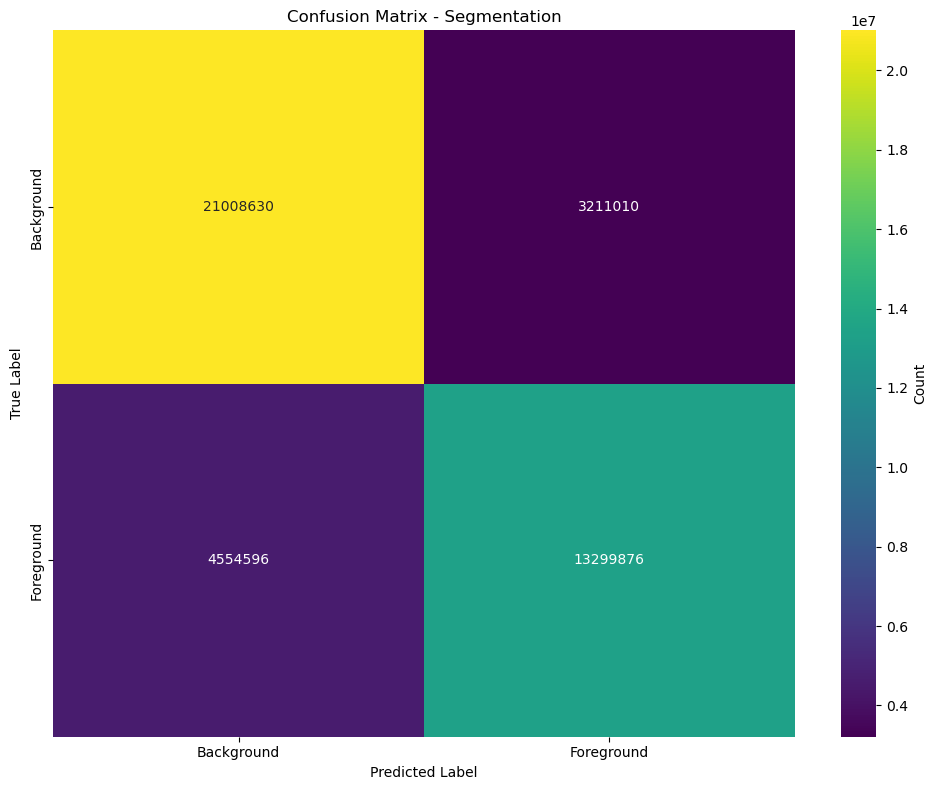

In [34]:
eval_models(model_mobilenet, test_class_seg, name="Fine-Tuned MobileNet")

In [35]:
import numpy as np

def print_best_epochs(history, model_name="Model"):
    hist = history.history

    best_val_loss_epoch = np.argmin(hist['val_loss']) + 1
    best_val_cls_acc_epoch = np.argmax(hist['val_classification_output_accuracy']) + 1
    best_val_seg_acc_epoch = np.argmax(hist['val_segmentation_output_accuracy']) + 1

    print(f"\nBest Epochs for {model_name}:")
    print(f"  Lowest val_loss: Epoch {best_val_loss_epoch} (val_loss = {hist['val_loss'][best_val_loss_epoch-1]:.4f})")
    print(f"  Best val_classification_accuracy: Epoch {best_val_cls_acc_epoch} (acc = {hist['val_classification_output_accuracy'][best_val_cls_acc_epoch-1]:.4f})")
    print(f"  Best val_segmentation_accuracy: Epoch {best_val_seg_acc_epoch} (acc = {hist['val_segmentation_output_accuracy'][best_val_seg_acc_epoch-1]:.4f})")


In [36]:
print_best_epochs(history_scratch, model_name="From-Scratch CNN")
print_best_epochs(history_mobilenet, model_name="MobileNetV3")


Best Epochs for From-Scratch CNN:
  Lowest val_loss: Epoch 14 (val_loss = 2.9534)
  Best val_classification_accuracy: Epoch 14 (acc = 0.2670)
  Best val_segmentation_accuracy: Epoch 14 (acc = 0.8552)

Best Epochs for MobileNetV3:
  Lowest val_loss: Epoch 8 (val_loss = 2.6467)
  Best val_classification_accuracy: Epoch 13 (acc = 0.5213)
  Best val_segmentation_accuracy: Epoch 12 (acc = 0.8921)


In [37]:
import matplotlib.pyplot as plt
def plot_training_history(history, model_name="Model"):
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(16, 10))

    # --- 1. Total Loss ---
    plt.subplot(2, 2, 1)
    plt.plot(epochs, hist['loss'], label='Train Loss')
    plt.plot(epochs, hist['val_loss'], label='Val Loss')
    plt.title(f"{model_name} - Total Loss")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # --- 2. Classification Accuracy ---
    plt.subplot(2, 2, 2)
    plt.plot(epochs, hist['classification_output_accuracy'], label='Train Acc')
    plt.plot(epochs, hist['val_classification_output_accuracy'], label='Val Acc')
    plt.title(f"{model_name} - Classification Accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # --- 3. Segmentation Accuracy ---
    plt.subplot(2, 2, 3)
    plt.plot(epochs, hist['segmentation_output_accuracy'], label='Train Acc')
    plt.plot(epochs, hist['val_segmentation_output_accuracy'], label='Val Acc')
    plt.title(f"{model_name} - Segmentation Accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # --- 4. Optional: Individual Task Losses ---
    if 'classification_output_loss' in hist:
        plt.subplot(2, 2, 4)
        plt.plot(epochs, hist['classification_output_loss'], label='Train Cls Loss')
        plt.plot(epochs, hist['segmentation_output_loss'], label='Train Seg Loss')
        plt.plot(epochs, hist['val_classification_output_loss'], label='Val Cls Loss')
        plt.plot(epochs, hist['val_segmentation_output_loss'], label='Val Seg Loss')
        plt.title(f"{model_name} - Task Losses")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

    plt.tight_layout()
    plt.show()

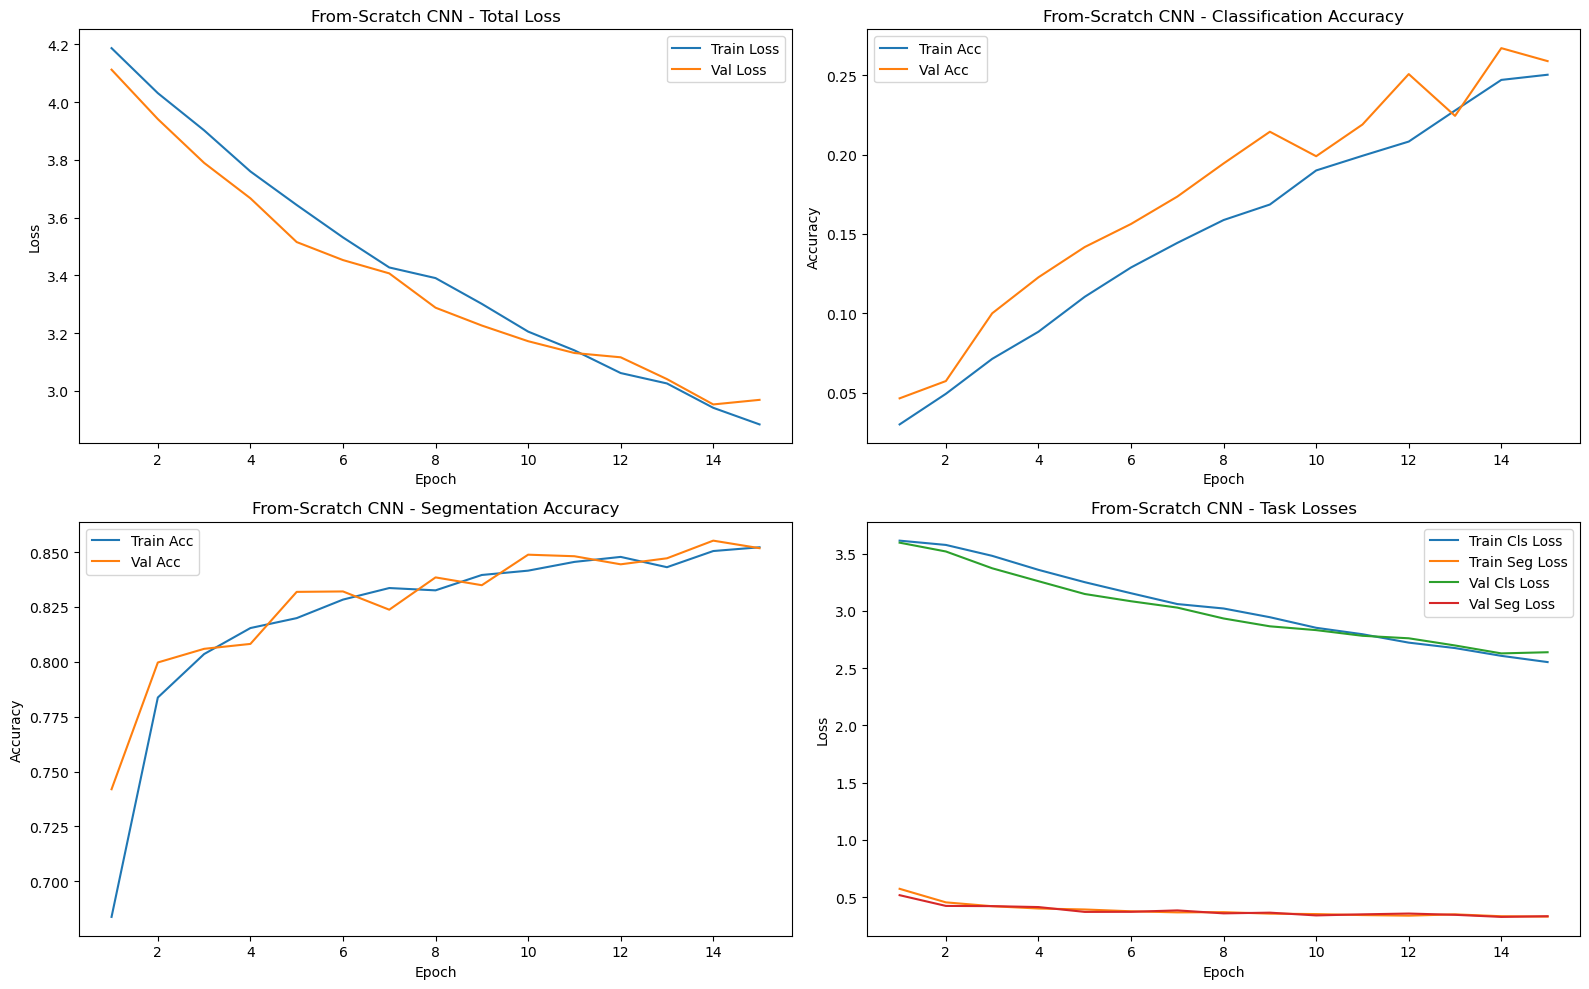

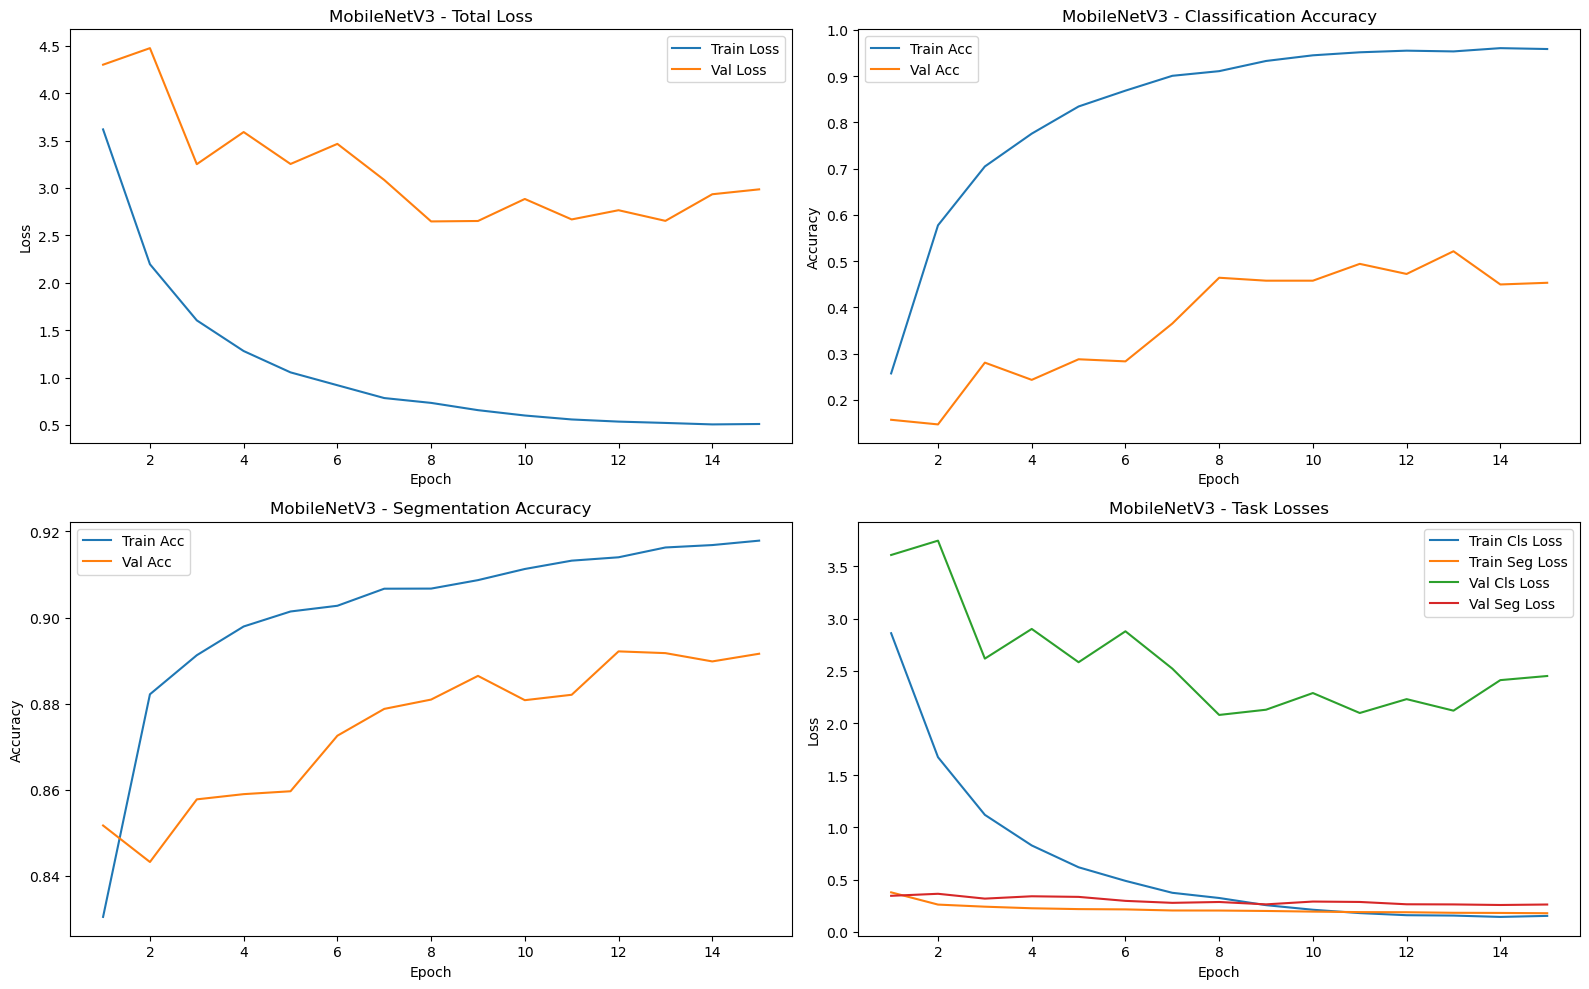

In [38]:
plot_training_history(history_scratch, model_name="From-Scratch CNN")
plot_training_history(history_mobilenet, model_name="MobileNetV3")

In [39]:
# For your write-up, you should include:
# - A discussion of what pre-processing (i.e. resizing, colour conversion, augmentation, etc.) you apply to the data and why.
# - Details of two implemented methods. This should include a details of the final “from-scratch” approach and justification 
#   for the chosen design, and details of changes made to MobileNetV3Small for the “fine-tuned” approach. Details on how the 
#   models are trained are also to be provided. 
# - An evaluation that compares the two models for the two tasks (classification and semantic segmentation). Your evaluation 
#   should discuss overall model performance, how it differs between the two approaches, and include figures if/where necessary.
# - A discussion of methods that were explored to improve performance for both models and mitigate identified issues, and potentially 
#   other methods that were considered but not implemented due to computational constraints. See the assignment brief for further 
#   details.
# Your write-up should be supported by appropriate figures and tables. Figures and tables should have numbers and meaningful captions.
# Note that figures and tables are not included in the page limits.
#
# SEE THE ASSIGNMENT BRIEF ON CANVAS FOR MORE DETAILS AND NOTE THAT A NOTEBOOK FILE DOES NOT CONSTITUTE A VALID SUBMISSION. 
# YOU SHOULD WRITE UP YOUR RESPONSE IN A SEPARATE DOCUMENT